In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from PIL import Image

img = Image.open("mona_lisa_public_domain.jpg")
print(img.size)

(2403, 3591)


In [3]:
img = img.convert("L")

width, height = img.size
new_height = 360
new_width = round(width * new_height / height)
img = img.resize((new_width, new_height))

X = np.asarray(img, dtype=float)
X = X / 255

In [4]:
n, p = X.shape
rank = np.linalg.matrix_rank(X)

print("n =", n)
print("p =", p)
print("rank(X) =", rank)
print("intensity range =", (X.min(), X.max()))

n = 360
p = 241
rank(X) = 241
intensity range = (np.float64(0.06274509803921569), np.float64(0.7529411764705882))


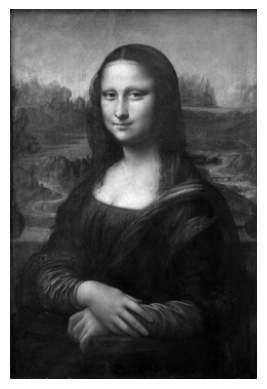

In [5]:
plt.imshow(X, cmap="gray")
plt.axis("off")
plt.show()

In [6]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
Sigma = np.diag(S)
V = Vt.T

U_error = np.linalg.norm(U.T @ U - np.eye(U.shape[1]), 2)
V_error = np.linalg.norm(V.T @ V - np.eye(V.shape[1]), 2)
reconstruction_error = np.linalg.norm(X - U @ Sigma @ Vt, "fro") / np.linalg.norm(X, "fro")

print("||U^T U - I||_2 =", U_error)
print("||V^T V - I||_2 =", V_error)
print("Relative reconstruction error =", reconstruction_error)

||U^T U - I||_2 = 4.789846103249491e-15
||V^T V - I||_2 = 5.189534921683942e-15
Relative reconstruction error = 6.644654239955792e-15


In [7]:
k = 1

Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

Xk = Uk @ Sk @ Vtk

print(Xk.shape)

(360, 241)


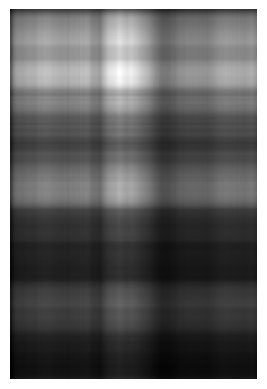

In [8]:
plt.imshow(np.clip(Xk, 0, 1), cmap="gray")
plt.axis("off")
plt.show()

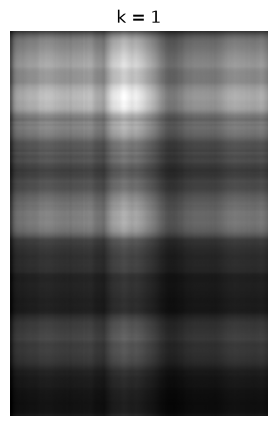

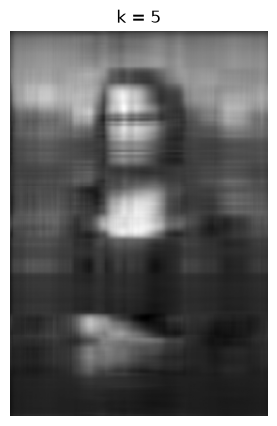

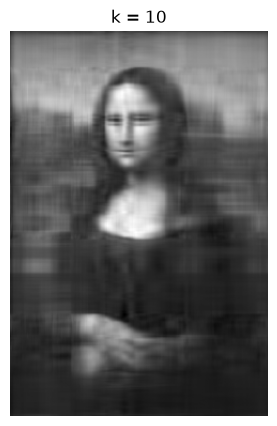

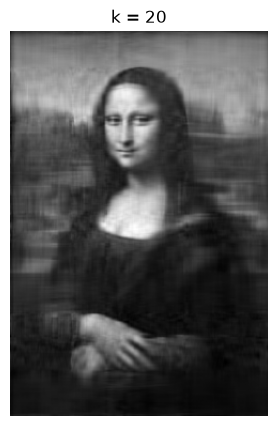

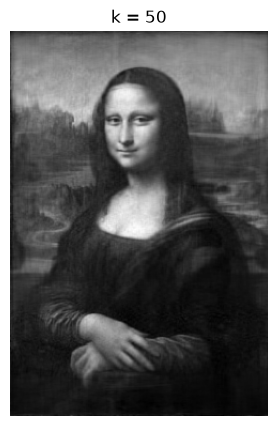

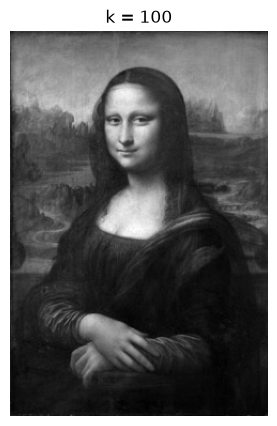

In [9]:
ks = [1, 5, 10, 20, 50, 100]

for k in ks:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    
    Xk = Uk @ Sk @ Vtk
    Xk_display = np.clip(Xk, 0, 1)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(Xk_display, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")
    plt.show()

In [10]:
ks = [1, 5, 10, 20, 50, 100]

for k in ks:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    
    Xk = Uk @ Sk @ Vtk
    
    actual_error = np.linalg.norm(X - Xk, "fro")
    theoretical_error = np.sqrt(np.sum(S[k:]**2))
    
    print(f"k = {k}")
    print("Actual error:", actual_error)
    print("Theoretical error:", theoretical_error)
    print("Difference:", abs(actual_error - theoretical_error))
    print()

k = 1
Actual error: 26.099967090462588
Theoretical error: 26.099967090462577
Difference: 1.0658141036401503e-14

k = 5
Actual error: 12.191919711474602
Theoretical error: 12.191919711474604
Difference: 1.7763568394002505e-15

k = 10
Actual error: 7.837508140654032
Theoretical error: 7.837508140654032
Difference: 0.0

k = 20
Actual error: 5.061121261895914
Theoretical error: 5.061121261895914
Difference: 0.0

k = 50
Actual error: 2.7564118010944583
Theoretical error: 2.7564118010944587
Difference: 4.440892098500626e-16

k = 100
Actual error: 1.3942609048183838
Theoretical error: 1.3942609048183838
Difference: 0.0



In [11]:
S_squared = S**2
total_energy = np.sum(S_squared)
cumulative_energy = np.cumsum(S_squared)
energy_share = cumulative_energy / total_energy

thresholds = [0.90, 0.95, 0.99]

for threshold in thresholds:
    k = np.argmax(energy_share >= threshold) + 1
    relative_error = np.sqrt(1 - energy_share[k - 1])
    
    print(f"{threshold*100:.0f}% energy:")
    print("Smallest k =", k)
    print("Retained energy =", energy_share[k - 1])
    print("Relative Frobenius error =", relative_error)
    print()

90% energy:
Smallest k = 1
Retained energy = 0.9066256712247722
Relative Frobenius error = 0.305572133505704

95% energy:
Smallest k = 3
Retained energy = 0.964746946588326
Relative Frobenius error = 0.1877579649753212

99% energy:
Smallest k = 9
Retained energy = 0.9903011037452856
Relative Frobenius error = 0.09848297444083637



Problemo 3

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
data = pd.read_csv("market_data_2007_2025.csv")

print(data.head())
print(data.shape)
print(data.columns)

         Date  SPY_Adj_Close  SPY_Volume  QQQ_Adj_Close  TLT_Adj_Close  \
0  2007-04-11     101.122330   106365700      37.893623      48.060932   
1  2007-04-12     101.571693   115534400      38.193630      48.071945   
2  2007-04-13     102.035133    84287000      38.270779      47.923416   
3  2007-04-16     103.004082    83064600      38.622173      48.187450   
4  2007-04-17     103.277870   108424100      38.707901      48.456974   

   HYG_Adj_Close  VIX_Close  
0      31.546604      13.49  
1      31.567768      12.71  
2      31.510342      12.20  
3      31.498220      11.98  
4      31.483103      12.14  
(4713, 7)
Index(['Date', 'SPY_Adj_Close', 'SPY_Volume', 'QQQ_Adj_Close', 'TLT_Adj_Close',
       'HYG_Adj_Close', 'VIX_Close'],
      dtype='str')


In [14]:
data = pd.read_csv("market_data_2007_2025.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

prices = data[
    [
        "SPY_Adj_Close",
        "QQQ_Adj_Close",
        "TLT_Adj_Close",
        "HYG_Adj_Close",
        "VIX_Close"
    ]
]

prices.columns = ["SPY", "QQQ", "TLT", "HYG", "VIX"]

# Daily log changes
log_changes = np.log(prices).diff().dropna()

# Financial series in rows, dates in columns
R = log_changes.T.to_numpy()

print("R shape:", R.shape)

R shape: (5, 4712)


In [15]:
U, S, Vt = np.linalg.svd(R, full_matrices=False)

In [16]:
print("R shape:", R.shape)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)

R shape: (5, 4712)
U shape: (5, 5)
S shape: (5,)
Vt shape: (5, 4712)


In [17]:
u1 = U[:]
sigma1 = S[0]
v1 = Vt[:]
print(v1)

[[-0.01115673 -0.00762264 -0.00371786 ...  0.00809012  0.00172383
   0.00805378]
 [ 0.00315204  0.0037349  -0.00838589 ... -0.00203229 -0.00012786
   0.00105846]
 [ 0.00256968 -0.00453852  0.0120552  ...  0.00460494 -0.00421886
  -0.0154202 ]
 [ 0.00578903  0.00462833  0.00960576 ... -0.00469893 -0.00503084
  -0.00574975]
 [ 0.00604284 -0.01139307 -0.01364368 ... -0.00117162  0.00090804
   0.00636236]]


u1 represents the strongest cross-sectional pattern across the five financial series. \(v_1\) represents the normalized temporal direction of this pattern, with one entry per date. The actual dated coefficients are given by \(\sigma_1v_1\), because the singular value \(\sigma_1\) provides the scale of the pattern.

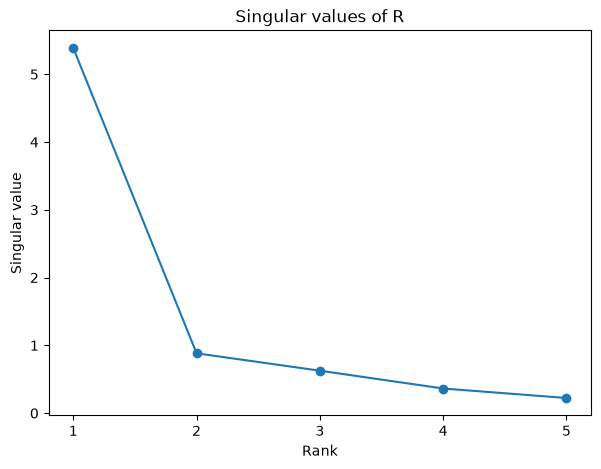

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(S) + 1), S, marker="o")
plt.xlabel("Rank")
plt.ylabel("Singular value")
plt.title("Singular values of R")
plt.xticks(range(1, len(S) + 1))
plt.show()

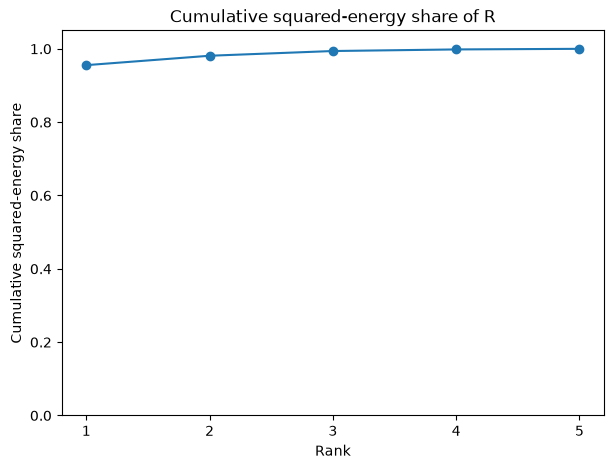

In [20]:
S_squared = S**2
energy_share = np.cumsum(S_squared) / np.sum(S_squared)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(S) + 1), energy_share, marker="o")
plt.xlabel("Rank")
plt.ylabel("Cumulative squared-energy share")
plt.title("Cumulative squared-energy share of R")
plt.xticks(range(1, len(S) + 1))
plt.ylim(0, 1.05)
plt.show()

In [21]:
u1 = U[:, 0]
sigma1 = S[0]
v1 = Vt[0, :]

In [22]:
print("Original u1:", u1)

Original u1: [-0.12068873 -0.13170532  0.03181971 -0.04341588  0.9824411 ]


In [24]:
if u1[0] < 0:
    u1 = -u1
    v1 = -v1

print("Oriented u1:")
print("SPY =", u1[0])
print("QQQ =", u1[1])
print("TLT =", u1[2])
print("HYG =", u1[3])
print("VIX =", u1[4])

Oriented u1:
SPY = 0.12068873150332901
QQQ = 0.13170531588643417
TLT = -0.03181970653113466
HYG = 0.04341587596687827
VIX = -0.9824410963745733


In [26]:
u1 = U[:, 0]
sigma1 = S[0]
v1 = Vt[0, :]

if u1[0] < 0:
    u1 = -u1
    v1 = -v1

print("sigma1 =", sigma1)
print("\nOriented u1:")
for asset, value in zip(["SPY", "QQQ", "TLT", "HYG", "VIX"], u1):
    print(f"{asset} = {value}")

coefficient_1 = sigma1 * v1[0]

print("\nFirst-date coefficient =", coefficient_1)

first_date_reconstruction = coefficient_1 * u1

print("\nFirst-date rank-one reconstruction:")
for asset, value in zip(["SPY", "QQQ", "TLT", "HYG", "VIX"], first_date_reconstruction):
    print(f"{asset} = {value}")

sigma1 = 5.387721217852777

Oriented u1:
SPY = 0.12068873150332901
QQQ = 0.13170531588643417
TLT = -0.03181970653113466
HYG = 0.04341587596687827
VIX = -0.9824410963745733

First-date coefficient = 0.060109330283255456

First-date rank-one reconstruction:
SPY = 0.007254518823400741
QQQ = 0.007916718332678162
TLT = -0.001912661249396234
HYG = 0.0026096992280299387
VIX = -0.059053876345822834


In [27]:
print("Actual first date:")
for asset, value in zip(["SPY", "QQQ", "TLT", "HYG", "VIX"], R[:, 0]):
    print(f"{asset} = {value}")

Actual first date:
SPY = 0.004433919059424696
QQQ = 0.007885904948465416
TLT = 0.00022912099069083425
HYG = 0.0006706536098008975
VIX = -0.05955956482150704


I+ = ['SPY', 'QQQ', 'HYG']

Weights:
SPY    0.407994
QQQ    0.445236
HYG    0.146770
dtype: float64


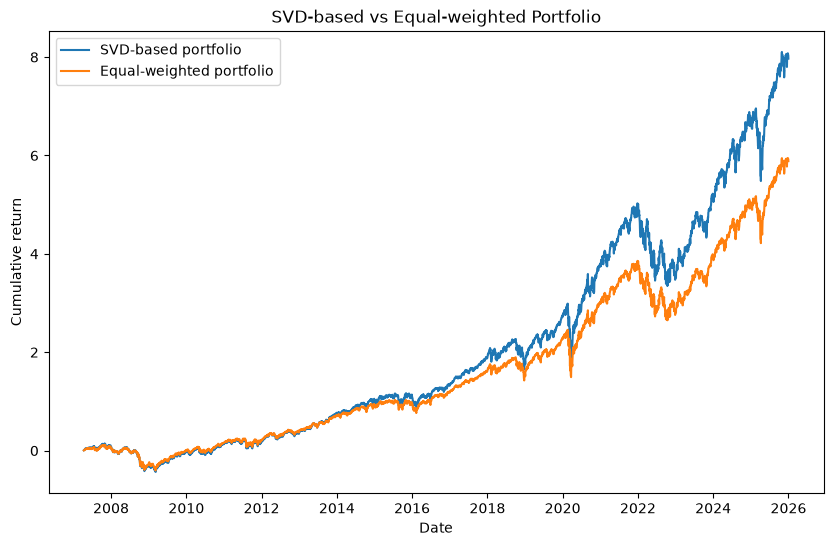

In [28]:
etfs = ["SPY", "QQQ", "TLT", "HYG"]

# Find the ETFs with a positive u1 coefficient
I_plus = [etf for etf, loading in zip(etfs, u1[:4]) if loading > 0]

# Calculate weights from the positive loadings
positive_loadings = pd.Series(u1[:4], index=etfs)[I_plus]
weights = positive_loadings / positive_loadings.sum()

print("I+ =", I_plus)
print("\nWeights:")
print(weights)

# Convert log changes to simple returns
simple_returns = np.exp(log_changes) - 1

# Calculate daily portfolio returns
portfolio_returns = simple_returns[I_plus] @ weights

# Equally weighted portfolio using the same ETFs
equal_returns = simple_returns[I_plus].mean(axis=1)

# Calculate cumulative returns
portfolio_cumulative = (1 + portfolio_returns).cumprod() - 1
equal_cumulative = (1 + equal_returns).cumprod() - 1

# Plot both
plt.figure(figsize=(10, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label="SVD-based portfolio")
plt.plot(equal_cumulative.index, equal_cumulative, label="Equal-weighted portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.title("SVD-based vs Equal-weighted Portfolio")
plt.legend()
plt.show()

The portfolio constructed from the positive loadings of the leading SVD component achieved a higher historical cumulative return than the equally weighted portfolio over the sample period.

In [29]:
for k in [1, 2, 3, 4]:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vtk = Vt[:k, :]
    
    Rk = Uk @ Sk @ Vtk
    
    print(f"k = {k}, Rk shape = {Rk.shape}")

k = 1, Rk shape = (5, 4712)
k = 2, Rk shape = (5, 4712)
k = 3, Rk shape = (5, 4712)
k = 4, Rk shape = (5, 4712)


In [30]:
energy_share = np.cumsum(S**2) / np.sum(S**2)

for k in [1, 2, 3, 4]:
    print(f"k = {k}, squared-energy share = {energy_share[k-1]:.4f}")

k = 1, squared-energy share = 0.9555
k = 2, squared-energy share = 0.9811
k = 3, squared-energy share = 0.9940
k = 4, squared-energy share = 0.9984


In [31]:
k = 2

U2 = U[:, :k]
S2 = np.diag(S[:k])
Vt2 = Vt[:k, :]

R2 = U2 @ S2 @ Vt2
residuals = R - R2

print("R2 shape:", R2.shape)
print("Residuals shape:", residuals.shape)

R2 shape: (5, 4712)
Residuals shape: (5, 4712)


In [32]:
dates = log_changes.index[-250:]
R_last = R[:, -250:]
R2_last = R2[:, -250:]
residuals_last = residuals[:, -250:]

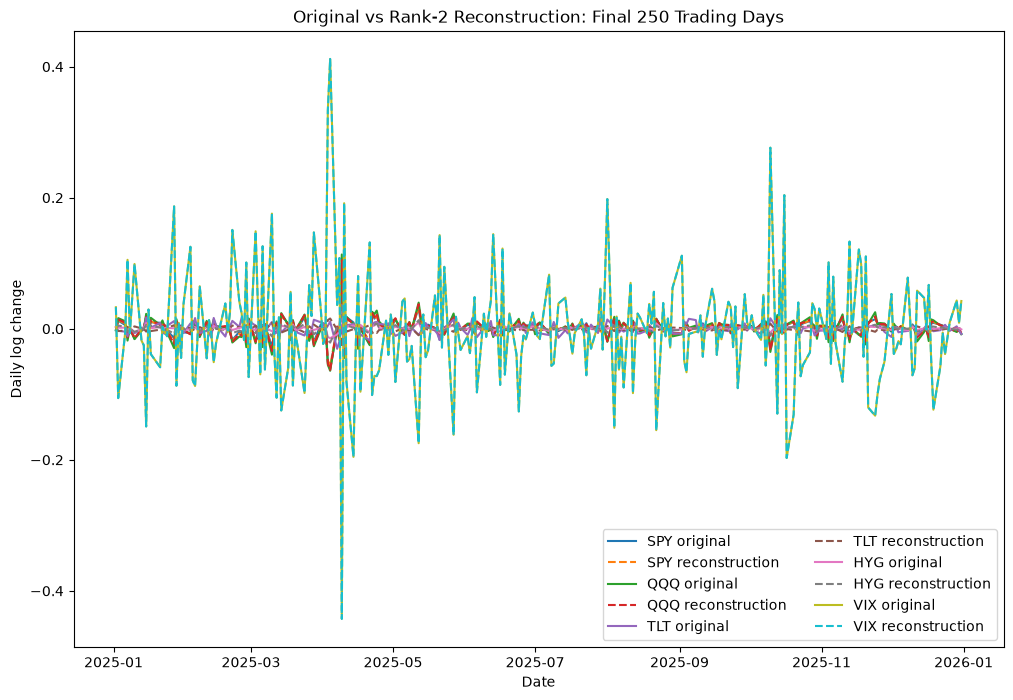

In [37]:
assets = ["SPY", "QQQ", "TLT", "HYG", "VIX"]

plt.figure(figsize=(12, 8))

for i, asset in enumerate(assets):
    plt.plot(dates, R_last[i], label=f"{asset} original")
    plt.plot(dates, R2_last[i], "--", label=f"{asset} reconstruction")

plt.xlabel("Date")
plt.ylabel("Daily log change")
plt.title("Original vs Rank-2 Reconstruction: Final 250 Trading Days")
plt.legend(ncol=2)
plt.show()

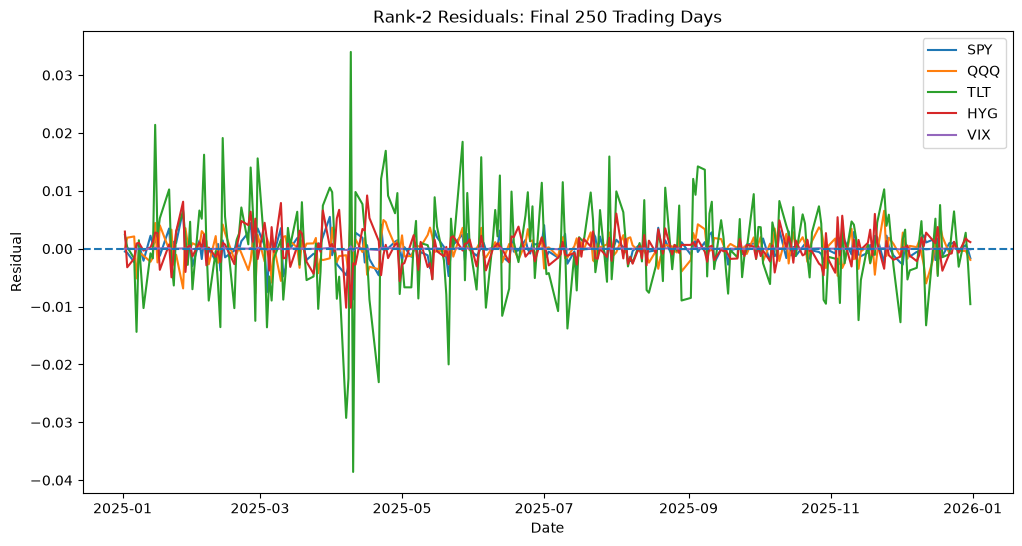

In [38]:
plt.figure(figsize=(12, 6))

for i, asset in enumerate(assets):
    plt.plot(dates, residuals_last[i], label=asset)

plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Rank-2 Residuals: Final 250 Trading Days")
plt.legend()
plt.show()

The portfolio weights were constructed using the same historical dates on which the cumulative performance was evaluated. Therefore, the reported performance is in-sample and does not provide evidence that the strategy will perform similarly on future, unseen data. A large singular value only indicates that the corresponding pattern explains a large amount of variation in the historical return matrix; it does not imply high future returns or profitability. Similarly, a higher historical cumulative return is only evidence of better performance over the observed sample and does not establish future profitability.